# K-Means

1. Dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Descargar dataset desde UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(url)

# Usar solo las columnas de gasto (excluir Channel y Region)
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[features].values.astype(float)

# Estandarizar
X = StandardScaler().fit_transform(X)

print('Shape:', X.shape)
df[features].describe().round(1)

Shape: (440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


Se descargan los datos y se conservan solo las 6 columnas de gasto, descartando Channel y Region que son categóricas. Luego se estandariza: cada feature queda con media 0 y desviación estándar 1.

2. Implementacion

In [6]:
def kmeans(X, k, max_iter=300, tol=1e-4):
    n = len(X)
    # Inicialización aleatoria: elegir k puntos del dataset
    idx = np.random.choice(n, k, replace=False)
    centroids = X[idx].copy()

    for it in range(1, max_iter + 1):
        # 1. Asignación: cada punto al centroide más cercano
        dists  = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)  # (n, k)
        labels = np.argmin(dists, axis=1)

        # 2. Actualización: nuevos centroides como media de cada cluster
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

        # Criterio de parada
        movement = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if movement < tol:
            break

    # Inercia: suma de distancias cuadradas al centroide asignado
    inertia = sum(np.sum((X[labels == j] - centroids[j])**2) for j in range(k))
    return labels, centroids, inertia, it


def kmeans_best(X, k, n_init=10):
    results = [kmeans(X, k) for _ in range(n_init)]
    return min(results, key=lambda r: r[2])

print('Funciones definidas.')

Funciones definidas.


Se eligen k puntos al azar del dataset como centroides iniciales. Para cada punto se calcula la distancia euclidiana a cada centroide. El punto se asigna al centroide más cercano. Se realiza una operación de broadcasting que calcula todas las distancias de una vez, produciendo una matriz de forma (n, k). Cada centroide se mueve al promedio de todos los puntos que tiene asignados. Se detiene si los centroides ya casi no se mueven (menos de 1e-4), o si se alcanza el máximo de iteraciones. Esto cubre los dos criterios del enunciado. Luego se calcula la inercia, que es la suma de distancias cuadradas de cada punto a su centroide. Mide qué tan compactos son los clusters, a menor inercia, mejor.
La función kmeans_best() simplemente corre kmeans() diez veces y se queda con el resultado de menor inercia, para evitar quedarse atrapado en un mínimo local por mala inicialización.

3. Ejecucion

In [7]:
resultados = {}
print(f'{'k':>3}  {'Inercia':>12}  {'Iteraciones':>12}')
print('-' * 32)
for k in [2, 3, 4, 5]:
    labels, centroids, inertia, n_iter = kmeans_best(X, k, n_init=10)
    resultados[k] = (labels, centroids, inertia, n_iter)
    print(f'{k:>3}  {inertia:>12.2f}  {n_iter:>12}')

  k       Inercia   Iteraciones
--------------------------------
  2       1954.04             5
  3       1614.52             6
  4       1345.47            20
  5       1070.46            16


Para cada valor de k se obtiene el mejor de 10 intentos. Se imprime la inercia y el número de iteraciones hasta convergencia. Estos valores son la materia prima para el método del codo.

4. Visualizacion

Metodo del codo

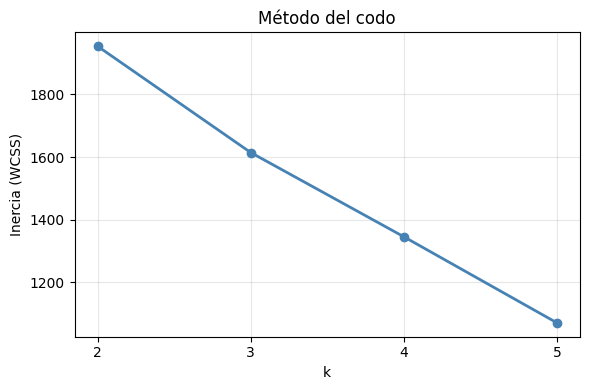

In [10]:
ks      = [2, 3, 4, 5]
inercias = [resultados[k][2] for k in ks]

plt.figure(figsize=(6, 4))
plt.plot(ks, inercias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('k'); plt.ylabel('Inercia (WCSS)')
plt.title('Método del codo')
plt.xticks(ks); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('codo.png', dpi=120)
plt.show()

Se grafica la inercia vs k. La inercia siempre baja al aumentar k (con más clusters los puntos quedan más cerca de su centroide), pero en algún punto la mejora se vuelve marginal. Ese punto de inflexión, donde la curva "dobla el codo", es el k óptimo. Si la caída entre k=2;3 es grande pero entre k=3;4 es pequeña, se elige k=3.

PCA para el k elegido

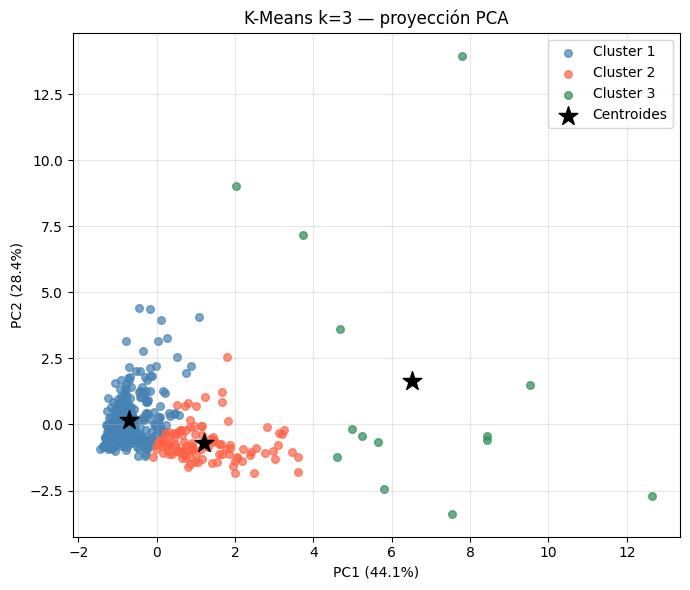

In [14]:
K_ELEGIDO = 3   # <-- cambia según el codo

labels, centroids, inertia, n_iter = resultados[K_ELEGIDO]

pca = PCA(n_components=2)
X2  = pca.fit_transform(X)
C2  = pca.transform(centroids)

colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']

plt.figure(figsize=(7, 6))
for j in range(K_ELEGIDO):
    mask = labels == j
    plt.scatter(X2[mask, 0], X2[mask, 1], c=colors[j], s=30,
                alpha=0.7, label=f'Cluster {j+1}')

plt.scatter(C2[:, 0], C2[:, 1], c='black', s=200, marker='*',
            zorder=5, label='Centroides')

var = pca.explained_variance_ratio_ * 100
plt.xlabel(f'PC1 ({var[0]:.1f}%)')
plt.ylabel(f'PC2 ({var[1]:.1f}%)')
plt.title(f'K-Means k={K_ELEGIDO} — proyección PCA')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=120)
plt.show()

Como los datos tienen 6 dimensiones no se pueden graficar directamente. PCA los proyecta a 2D conservando la mayor varianza posible. Los centroides se proyectan con el mismo transform para que queden en el mismo espacio.

5. Resultados

In [15]:
print('=' * 55)
print(f'MODELO FINAL  k = {K_ELEGIDO}')
print('=' * 55)
print(f'Inercia      : {inertia:.2f}')
print(f'Iteraciones  : {n_iter}')
print(f'Varianza PCA : PC1={var[0]:.1f}%  PC2={var[1]:.1f}%')
print()
print('Centroides (espacio original, sin estandarizar):')

# Deshacer estandarización para mostrar en unidades originales
scaler = StandardScaler().fit(df[features].values.astype(float))
centroids_orig = scaler.inverse_transform(centroids)
df_cent = pd.DataFrame(centroids_orig, columns=features,
                        index=[f'Cluster {j+1}' for j in range(K_ELEGIDO)])
print(df_cent.round(1).to_string())

MODELO FINAL  k = 3
Inercia      : 1614.52
Iteraciones  : 6
Varianza PCA : PC1=44.1%  PC2=28.4%

Centroides (espacio original, sin estandarizar):
             Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster 1  13599.2   3050.8   3858.0   3281.0             854.6      1169.0
Cluster 2   5591.4  10113.0  15637.4   1499.9            6711.4      1759.1
Cluster 3  26266.9  33847.8  39952.3  10703.4           18539.1      7718.1
